In [1]:
from Observation import *

import os
import numpy as np
from astropy.io import fits

from matplotlib import pyplot as plt
import matplotlib as mpl
from cycler import cycler
from matplotlib.colors import LogNorm

colors = iter([plt.cm.Set1(i) for i in range(20)])
default_cycler = cycler(color=colors)
plt.rc('axes', prop_cycle=default_cycler)

font = {'size'   : 22, 'family': 'serif'}
mpl.rc('font', **font)

Here is a basic tutorial on how to use this EMIR GTC pipeline. This pipeline is broken up into 5 steps for each needed spectrum:

1. Object and File System Initialization
2. Rectification and Calibration
3. ABBA Subtraction
4. Sensitivity Function + Telluric Correction
5. Flux Conversion

All of the steps can be done in a few lines after the object instantiation, as follows. In this example, OB0011 is the supernova spectrum and OB0012 is the standard A0V star HIP23671. The tabulated magnitudes for this star are used to calibrate the flux, those were found [here](http://research.iac.es/proyecto/emir/media/Telluric_standards/XHIP-A0V.dat). 

In this tutorial, the generation of the sensitivity function is not gone over in detail. To see a detailed example of the sensitivity function generation, take a look at the notebook in this directory called `OB0012_sensitivity_function.ipynb`



If this is the first time running this notebook, the next box will take a few minutes to run.

In [2]:
GRISM = 'YJ'

# reduce the spectrum up until the sensitivity function and telluric corrections are needed
o = Observation("OB0011")

if not os.path.exists('OB0011/results/ABBA/ABBA_subtracted_%s.fits'%GRISM):
    o.initialize('object', GRISM)
    o.rectify_and_analyze('object',GRISM)
    o.ABBA_subtract(GRISM)
    
# reduce OB0012 and create the sensitivity function and telluric corrections 
o12 = Observation("OB0012")

if not os.path.exists('OB0012/results/ABBA/ABBA_subtracted_%s.fits'%GRISM):
    o12.initialize('object', GRISM)
    o12.rectify_and_analyze('object',GRISM)
    o12.ABBA_subtract(GRISM)
    o12.make_sens_function(GRISM)

# flux standardization
h = get_header(o12, 1)
print('object name:', h['OBJECT']) # so you can get the tabulated magnitudes for this object
magnitudes = {
    'J': 7.710,
    'H': 7.776,
    'K': 7.736,
}

wave, flux = o.get_reduced_spectrum(magnitudes, o12, GRISM)

object name: HIP23671_SN2022xkq


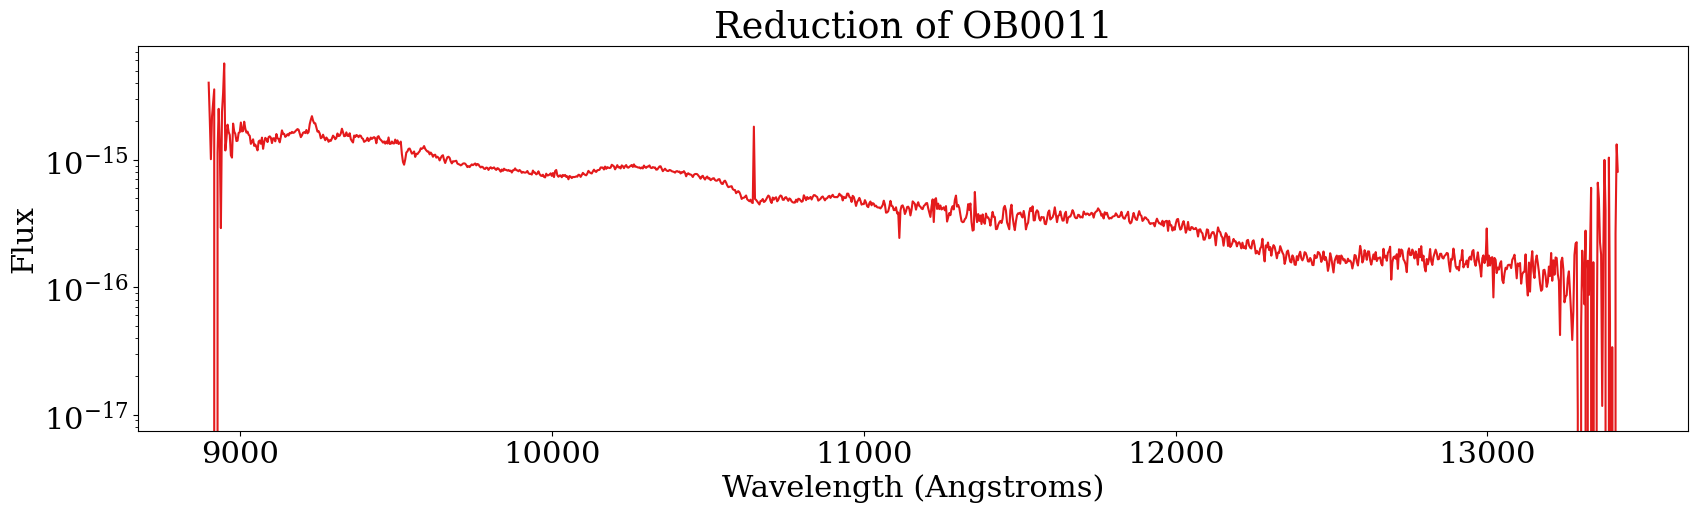

In [3]:
fig, ax = plt.subplots(1,1, figsize=(20,5))
ax.plot(wave, flux)
ax.set_xlabel('Wavelength (Angstroms)') ; ax.set_ylabel('Flux')
ax.set_yscale('log')
ax.set_title("Reduction of OB0011")

plt.show()

In [4]:
# let's start from scratch and clean the results folder
o._clean_files()

If you just want to blindly run the pipeline, you can stop here. In the rest of the notebook, I will outline what each step does and what its outputs are.

# Raw Data Inputs

Before we start analyzing the data, you should know the directory structure that is expected of the raw data inputs. In this notebook, we will be using an observation called OB0011, whose data is in the same directory as this notebook. Let's look at the directory structure:

In [5]:
[f for f in os.listdir("OB0011/") if f[0]!='.']

['GTCMULTIPLE2A-22B_0011_qc.txt', 'flat', 'object', 'arc']

Let's go through these one-by-one:
- `GTCMULTIPLE2A-22B_0011_qc.txt`: This is the quality control files generated by the EMIR outputs. This lists which file was done with which GRISM, in which position (A or B), and much more information. This file must be included in the observation directory.
- `object`: This is the directory that holds the raw data files for the object we are trying to get the spectrum for
- `flat`: This is an optional directory used to make flat fields for the data. If it is not included, it will copy the flat field from the EMIR defaults. 
- `arc`: This is the readings from the arc lamp with known wavelengths. This data can be rectified and calibrated, but using this calibration for the flux conversions for the object is not yet supported. 

# Object and File System Initialization

### Object Instantiation

First, we create an Observation object, the implementation of which is in `path/to/EMIR_pipeline/src/Observation.py`. Virtually all of the code in this pipeline is written in this file. Some quick documentation of the `Observation` constructor:

__```Observation(observation_dir, result_dir=None)```__

Constructor for an Observation object.

  Arguments:
    
   - `observation_dir (str)`: the path to the raw outputs of EMIR (see above the required directory structure)
   - `result_dir (str, optional)`: the path where the results of the pipeline will be stored. Defaults to `observation_dir`
   
  Outputs:
   - `Observation` object 
   - EMIR directory built in the `result_dir` path
   
   
Let's instantiate the object and see what happens:

In [6]:
o = Observation("OB0011")

Once this has been run, you'll see a new EMIR directory in `OB0011/results/EMIR_files` populated with some basic files. Importantly, there are observation result files for both the arc and object files, as well as control files, all for each GRISM used in the quality control file. Within the `OB0011/results/EMIR_files/data` directory, you will also see some basic files needed to run the analyses, including flat field files for each GRISM. If your `observation_dir` has a `flat` directory, the addition of these flat fields will automatically be generated and stored when the Object is initialized:

In [7]:
print("Default Analysis Files & Generated Flats:")
preliminary_files = [f for f in os.listdir("OB0011/results/EMIR_files/data")]
preliminary_files

Default Analysis Files & Generated Flats:


['rect_wpoly_MOSlibrary_grism_LR_filter_HK.json',
 'rect_wpoly_MOSlibrary_grism_H_filter_H.json',
 'master_dark_zeros.fits',
 'rect_wpoly_MOSlibrary_grism_J_filter_J.json',
 'master_flat_YJ.fits',
 'rect_wpoly_MOSlibrary_grism_LR_filter_YJ.json',
 'master_bpm.fits',
 'master_flat_HK.fits',
 'master_flat_ones.fits',
 'rect_wpoly_MOSlibrary_grism_K_filter_Ksp.json']

### Analysis Initialization
Now we will start the analysis by initializing the files for a certain GRISM. Here is some documentation for how this function works:

__```Observation.initialize(analysis_type, GRISM)```__

Initializes the EMIR analysis directory for a numina run.

  Arguments:
    
   - `analysis_type (str)`: which file set you want to initialize (options: object, arc)
   - `GRISM (str)`: the GRISM you want to analyze (options: J, YJ, HK, etc. depending on your quality control file)
   
  Outputs:
   - None
   - Must be run before starting an analysis on an observation


In this example, we will start the analysis on the `YJ` GRISM. To do this, we must initialize the correct files for this analysis as follows.  

In [8]:
o.initialize('object', GRISM)

This function largely just copies the correct files into the `OB0011/results/EMIR_files/data` directory for the PyEMIR numina run:

In [9]:
print("New files in the data directory:")
[f for f in os.listdir("OB0011/results/EMIR_files/data") if f not in preliminary_files]

New files in the data directory:


['0003705826-20221104-EMIR-STARE_SPECTRA.fits',
 '0003705839-20221104-EMIR-STARE_SPECTRA.fits',
 '0003705813-20221104-EMIR-STARE_SPECTRA.fits',
 '0003705800-20221104-EMIR-STARE_SPECTRA.fits']

And now we're ready to do rectification and calibration!

# Rectification and Calibration

__```Observation.rectify_and_analyze(analysis_type, GRISM)```__

Rectifies the raw spectrum data and calibrates the x-axis to wavelength.

  Arguments:
    
   - `analysis_type (str)`: which file set you want to initialize (options: object, arc)
   - `GRISM (str)`: the GRISM you want to analyze (options: J, YJ, HK, etc. depending on your quality control file)
   
  Outputs:
   - Generates the rectified and calibrated image and saves to `obsid[Observation.name]_[observation ID]_results/reduced_mos.fits`

In [10]:
o.rectify_and_analyze('object', GRISM)

In [11]:
print("Rectify and Calibrate outputs:")
work_dirs = [f for f in os.listdir('OB0011/results/EMIR_files/') if f[:5]=="obsid" and f[-4:]=="work"]
work_dirs

Rectify and Calibrate outputs:


['obsidOB0011_0003705800_work',
 'obsidOB0011_0003705826_work',
 'obsidOB0011_0003705813_work',
 'obsidOB0011_0003705839_work']

Let's look at the before and after:

In [12]:
before_fname = "OB0011/object/0003705800-20221104-EMIR-STARE_SPECTRA.fits"
after_fname = "OB0011/results/EMIR_files/obsidOB0011_0003705800_results/reduced_mos.fits"

before_im = fits.open(before_fname)[0].data
after_im = fits.open(after_fname)[0].data

after_header = fits.open(after_fname)[0].header

# image dimensions
naxis2, naxis1 = after_im.shape

# read wavelength calibration from header
crpix1 = after_header['crpix1']
crval1 = after_header['crval1']
cdelt1 = after_header['cdelt1']
exptime = after_header['exptime']
print('crpix1, crval1, cdelt1:', crpix1, crval1, cdelt1)
print('exptime:', exptime)

crpix1, crval1, cdelt1: 1.0 8900.0 3.56
exptime: 119.996155


In [13]:
fig, axs = plt.subplots(1,2, figsize=(30,30), sharey=True)

axs[0].imshow(before_im, norm=LogNorm(vmin=100, vmax=200)) 
#axs[0].set_title("Before\n")
axs[0].set_xlabel("\nPixels", fontsize=35)

axs[1].imshow(after_im, norm=LogNorm(vmin=100, vmax=200)) 
#axs[1].set_title("After\n")

labels=[float(t) for t in axs[1].get_xticks().tolist()]
new_labels = [crval1 + (t - crpix1) * cdelt1 for t in labels]

axs[1].set_xticklabels(labels)
axs[1].set_xticklabels(new_labels)
axs[1].set_xlabel("\nWavelength (Angstroms)", fontsize=35)

plt.show()

/var/folders/nt/7hp8jjq563b09vy01vqx17dh0000gn/T/ipykernel_84825/2446225441.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1].set_xticklabels(labels)
/var/folders/nt/7hp8jjq563b09vy01vqx17dh0000gn/T/ipykernel_84825/2446225441.py:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1].set_xticklabels(new_labels)


Looks much better! Now we can move on to the ABBA subtraction.

# ABBA Subtraction

__```Observation.ABBA_subtract(GRISM)```__

Performs an ABBA subtraction on a set of object files in a given GRISM.

  Arguments:
    
   - `GRISM (str)`: the GRISM you want to analyze (options: J, YJ, HK, etc. depending on your quality control file)
   
  Outputs:
   - Generates the ABBA image and saves to `results/ABBA/ABBA_subtracted_[GRISM].fits`

In [14]:
o.ABBA_subtract(GRISM)

Simple enough. Let's look at the (zoomed in) results:

In [15]:
ABBA_fname = "OB0011/results/ABBA/ABBA_subtracted_%s.fits"%GRISM
ABBA_fits = fits.open(ABBA_fname)[1]
im = ABBA_fits.data
header = ABBA_fits.header

# image dimensions
naxis2, naxis1 = im.shape

# read wavelength calibration from header
crpix1 = header['crpix1']
crval1 = header['crval1']
cdelt1 = header['cdelt1']
exptime = header['exptime']

print(naxis2, naxis1)
print('crpix1, crval1, cdelt1:', crpix1, crval1, cdelt1)
print('exptime:', exptime)


2090 1270
crpix1, crval1, cdelt1: 1.0 8900.0 3.56
exptime: 119.996155


/var/folders/nt/7hp8jjq563b09vy01vqx17dh0000gn/T/ipykernel_84825/625336141.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(new_labels)


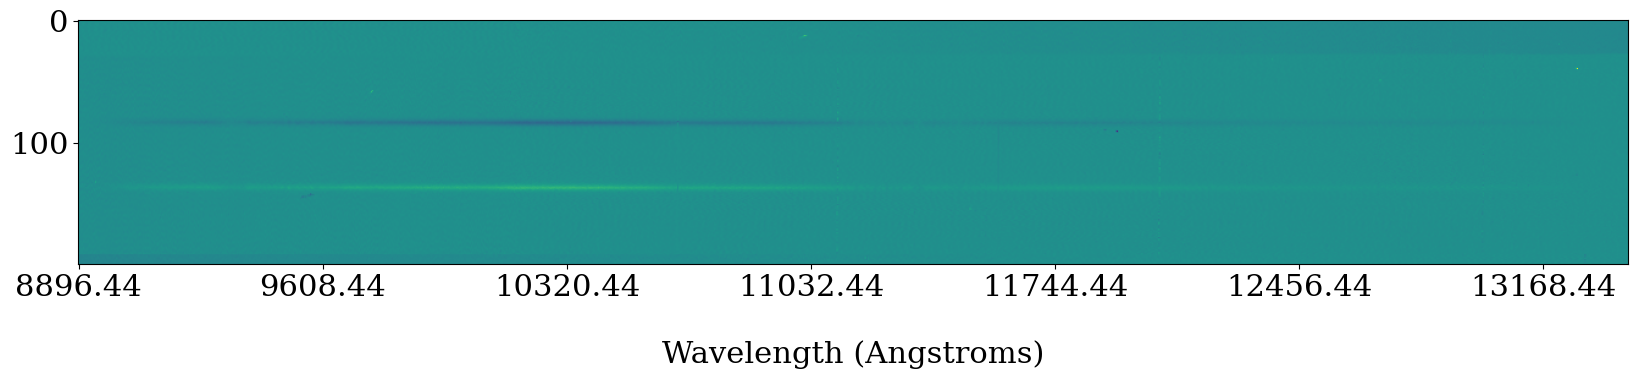

In [16]:
fig, ax = plt.subplots(1,1, figsize=(20,10))

ax.imshow(im[1100:1300])

labels=[float(t) for t in axs[1].get_xticks().tolist()]
new_labels = [crval1 + (t - crpix1) * cdelt1 for t in labels]

ax.set_xticklabels(new_labels)
ax.set_xlabel("\nWavelength (Angstroms)")

plt.show()

There's our signals! Next: Flux Calibration

# Flux Calibration

In order to do the flux calibration, you must create a sensitivity function for the data. The documentation for the functions needed for the flux calbration are in `OB0012_sensitivity_function.ipynb` in this directory. Here, we will just run the basic commands needed to get a reduced spectrum for OB0011:

In [17]:
o12 = Observation("OB0012")

if not os.path.exists('OB0012/results/sens_function/%s_sens_fn.fits'%GRISM):
    o12.initialize('object', GRISM)
    o12.rectify_and_analyze('object',GRISM)
    o12.ABBA_subtract(GRISM)
    o12.get_sens_function(GRISM)

Now, we can run the following function to get the final sensitivity function. 

__```Observation.get_reduced_spectrum(calibration_obs, GRISM, **kwargs)```__

Converts the raw counts into fluxes.

  Arguments:
    
   - `calibration_obs (Observation)`: the observation object for which the sensitivity function was generated
   - `GRISM (str)`: the GRISM you want to analyze (options: J, YJ, HK, etc. depending on your quality control file)
   - `kwargs (dict)`: a dictionary of keyword arguments to customize outputs for the data
   
  Outputs:
   - wave: the calibrated wavelength array (x-axis)
   - spectrum: the flux array (y-axis)
   
   
available kwargs:
- `SN_position`: y-axis position of the supernova on the raw data image (these can be manually or interactively done)

In [18]:
wave, flux = o.get_reduced_spectrum(magnitudes, o12, GRISM)

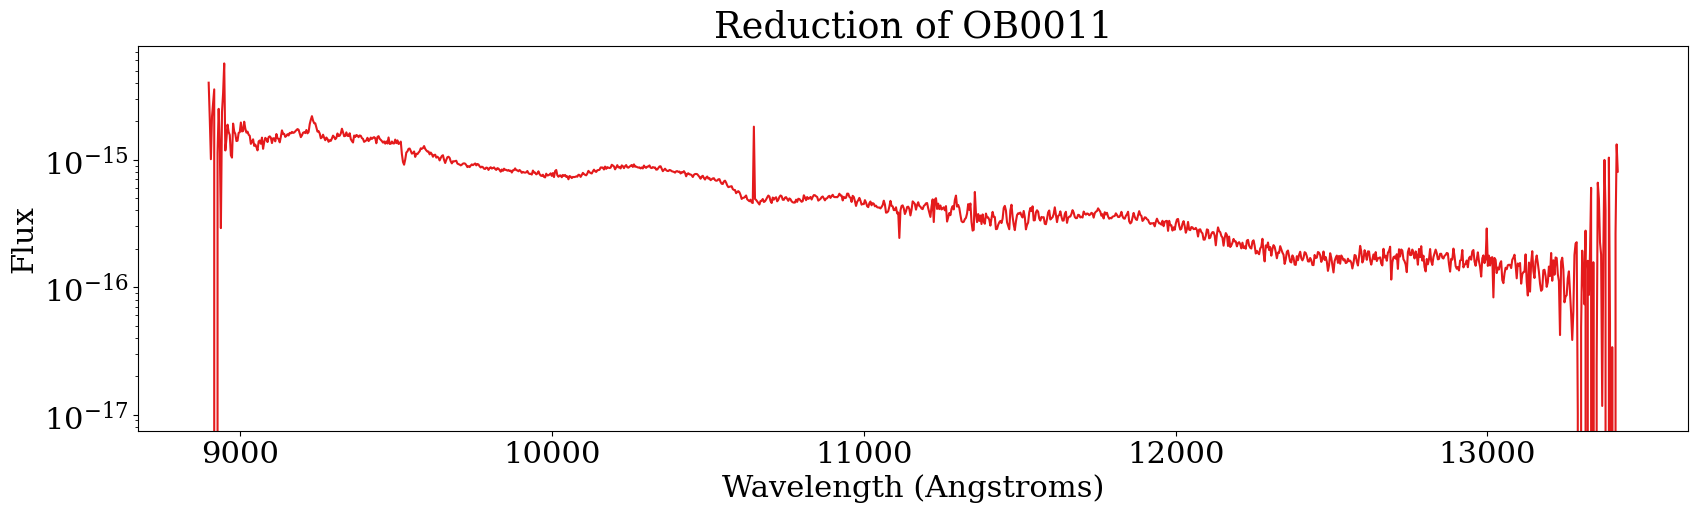

In [19]:
fig, ax = plt.subplots(1,1, figsize=(20,5))
ax.plot(wave, flux)
ax.set_xlabel('Wavelength (Angstroms)') ; ax.set_ylabel('Flux')
ax.set_yscale('log')
ax.set_title("Reduction of OB0011")

plt.show()

# Saving the Final Spectrum

__```Observation.save_spectrum(fname)```__

Saves all desired grisms in one file with useful header information.

  Arguments:
    
   - `fname` (`str`): name of the output file
   
  Outputs:
   - Generates the full spectrum on all GRISMs processed using `get_reduced_spectrum`

In [20]:
o.save_spectrum('OB0011/results/final_spectrum.txt')